# **Step 3 — K-Means Customer Segmentation**
**Project:** E-commerce Customer Segmentation  
**Input:** `rfm_table.csv` (from Step 2)  
**Goal:** Group customers into segments using K-Means, name them, and export the final labelled data.


In [3]:
from google.colab import files
uploaded = files.upload()

Saving rfm_table.csv to rfm_table.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os

In [5]:
os.makedirs('charts', exist_ok=True)

In [6]:
rfm = pd.read_csv('rfm_table.csv')

In [7]:
len(rfm)

5878

In [8]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,325,12,77556.46
1,12347,2,8,5633.32
2,12348,75,5,2019.40
3,12349,18,4,4428.69
4,12350,310,1,334.40


##  The distributions

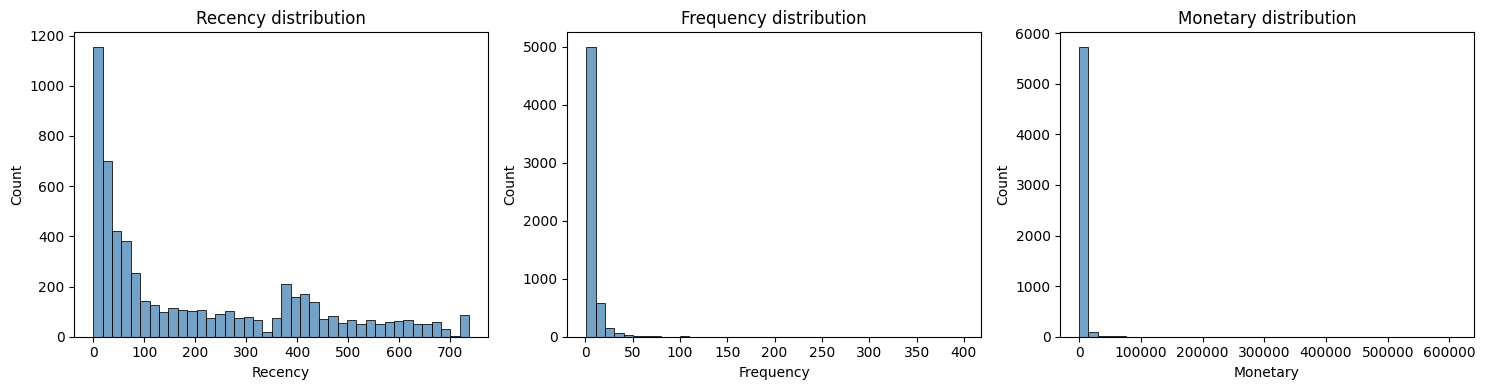

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.histplot(rfm[col], bins=40, ax=ax, color='steelblue')
    ax.set_title(f'{col} distribution')
plt.tight_layout()
plt.savefig('charts/03_rfm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

RFM data is skewed

In [10]:
rfm[['Recency','Frequency','Monetary']].describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,200.866791,6.289384,3018.616734
std,209.353961,13.009406,14737.731038
min,0.000000,1.000000,2.950000
25%,25.000000,1.000000,348.762500
50%,95.000000,3.000000,898.915000
75%,379.000000,7.000000,2307.090000
max,738.000000,398.000000,608821.650000


## Handle outliers
Notice the Monetary and Frequency columns have extreme outliers — a few wholesale-scale customers spending hundreds of thousands of pounds.


**We cap (clip) values at the 99th percentile.** This keeps every customer in the dataset but stops a handful of extreme values from dominating the clustering.


In [11]:
rfm_capped = rfm.copy()

for col in ['Frequency', 'Monetary']:
    cap_value = rfm_capped[col].quantile(0.99)
    n_capped = (rfm_capped[col] > cap_value).sum()
    rfm_capped[col] = rfm_capped[col].clip(upper=cap_value)
    print(f'{col}: capped {n_capped} customers at {cap_value:,.0f}')

rfm_capped[['Recency','Frequency','Monetary']].describe()


Frequency: capped 58 customers at 46
Monetary: capped 59 customers at 29,730


,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,200.866791,5.785471,2352.912283
std,209.353961,7.630332,4338.246316
min,0.000000,1.000000,2.950000
25%,25.000000,1.000000,348.762500
50%,95.000000,3.000000,898.915000
75%,379.000000,7.000000,2307.090000
max,738.000000,46.000000,29730.420200


## Scale the features
Recency is in days (0-700+), Monetary is in pounds (0-100,000+). K-Means uses distance, so without scaling, Monetary would completely dominate the result just because its numbers are bigger. `StandardScaler` puts all 3 features on the same scale (mean=0, std=1).


In [12]:
features = ['Recency', 'Frequency', 'Monetary']
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_capped[features])

print('Before scaling (first row):', rfm_capped[features].iloc[0].values)
print('After scaling (first row): ', rfm_scaled[0].round(2))


Before scaling (first row): [3.25000000e+02 1.20000000e+01 2.97304202e+04]
After scaling (first row):  [0.59 0.81 6.31]


## Find the best number of clusters (k)
We test k = 2 to 10 using two methods:
- **Elbow method**: plots inertia (how tight clusters are). Look for where the curve bends like an elbow.
- **Silhouette score**: measures how well-separated clusters are (closer to 1 = better, closer to 0 = overlapping).


In [13]:
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, labels))
    print(f'k={k}: inertia={km.inertia_:.0f}, silhouette={sil_scores[-1]:.3f}')


k=2: inertia=10067, silhouette=0.649
k=3: inertia=5333, silhouette=0.530
k=4: inertia=3696, silhouette=0.525
k=5: inertia=2983, silhouette=0.494
k=6: inertia=2417, silhouette=0.469
k=7: inertia=2090, silhouette=0.472
k=8: inertia=1800, silhouette=0.444
k=9: inertia=1570, silhouette=0.437
k=10: inertia=1427, silhouette=0.440


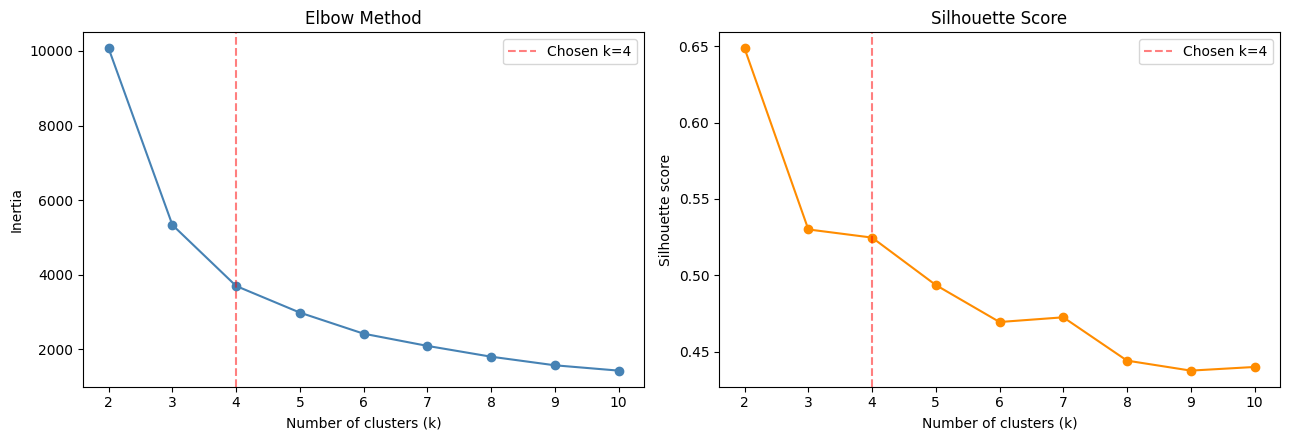

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(K_range, inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.5, label='Chosen k=4')
axes[0].legend()

axes[1].plot(K_range, sil_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].axvline(x=4, color='red', linestyle='--', alpha=0.5, label='Chosen k=4')
axes[1].legend()

plt.tight_layout()
plt.savefig('charts/04_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

**Choosing k=4.** The elbow starts flattening around k=4-5, and silhouette score is highest/stable in that range while still giving business-interpretable groups. Too many clusters (k=8+) becomes hard to act on in marketing — 4 clean segments is both statistically reasonable and practically useful.


## Fit the final K-Means model


In [15]:
final_k = 4
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
rfm_capped['Cluster'] = kmeans.fit_predict(rfm_scaled)

final_sil = silhouette_score(rfm_scaled, rfm_capped['Cluster'])
print(f'Final model: k={final_k}, silhouette score={final_sil:.3f}')
print()
print('Customers per cluster:')
print(rfm_capped['Cluster'].value_counts().sort_index())


Final model: k=4, silhouette score=0.525

Customers per cluster:
Cluster
0    1868
1    3000
2     202
3     808
Name: count, dtype: int64


## Profile each cluster
Now look at the average Recency, Frequency, and Monetary for each cluster to understand what kind of customer it represents.


In [16]:
cluster_profile = rfm_capped.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(1)
cluster_profile['CustomerCount'] = rfm_capped['Cluster'].value_counts().sort_index()
cluster_profile['Pct_of_Customers'] = (cluster_profile['CustomerCount'] / len(rfm_capped) * 100).round(1)
cluster_profile

,Recency,Frequency,Monetary,CustomerCount,Pct_of_Customers
Cluster,,,,,
0,474.9,2.0,668.3,1868,31.8
1,83.5,3.8,1207.3,3000,51.0
2,36.6,34.1,20695.4,202,3.4
3,44.1,14.8,5915.7,808,13.7


## 8. Name the segments based on the profile

- **Low Recency + High Frequency + High Monetary** → these are your best customers → **Champions**
- **Low Recency + Moderate Frequency/Monetary** → buy somewhat regularly → **Loyal Customers**
- **High Recency + Low Frequency/Monetary** → haven't bought in a long time → **At Risk / Lost**
- **Moderate Recency + Low Frequency** → newer or occasional buyers → **Regular / New Customers**



In [17]:
# Look at the profile table above, then edit this mapping to match your cluster numbers
# Sort clusters by Monetary value to help auto-assign sensible names
sorted_clusters = cluster_profile.sort_values('Monetary', ascending=False).index.tolist()


In [18]:
# Default naming based on rank (highest spend = Champions, lowest = At Risk/Lost)
# Review this against YOUR actual cluster_profile table above and adjust if needed
segment_names = {
    sorted_clusters[0]: 'Champions',
    sorted_clusters[1]: 'Loyal Customers',
    sorted_clusters[2]: 'At Risk',
    sorted_clusters[3]: 'Lost'
}

In [19]:
print('Cluster -> Segment name mapping:')
for cluster_id, name in segment_names.items():
    print(f'  Cluster {cluster_id} -> {name}')

rfm_capped['Segment'] = rfm_capped['Cluster'].map(segment_names)
rfm_capped[['CustomerID','Recency','Frequency','Monetary','Cluster','Segment']].head(10)


Cluster -> Segment name mapping:
  Cluster 2 -> Champions
  Cluster 3 -> Loyal Customers
  Cluster 1 -> At Risk
  Cluster 0 -> Lost


,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,325,12,29730.4202,2,Champions
1,12347,2,8,5633.3200,3,Loyal Customers
2,12348,75,5,2019.4000,1,At Risk
3,12349,18,4,4428.6900,1,At Risk
4,12350,310,1,334.4000,0,Lost
5,12351,375,1,300.9300,0,Lost
6,12352,36,10,2849.8400,1,At Risk
7,12353,204,2,406.7600,1,At Risk
8,12354,232,1,1079.4000,1,At Risk
9,12355,214,2,947.6100,1,At Risk



##  Visualize the segments

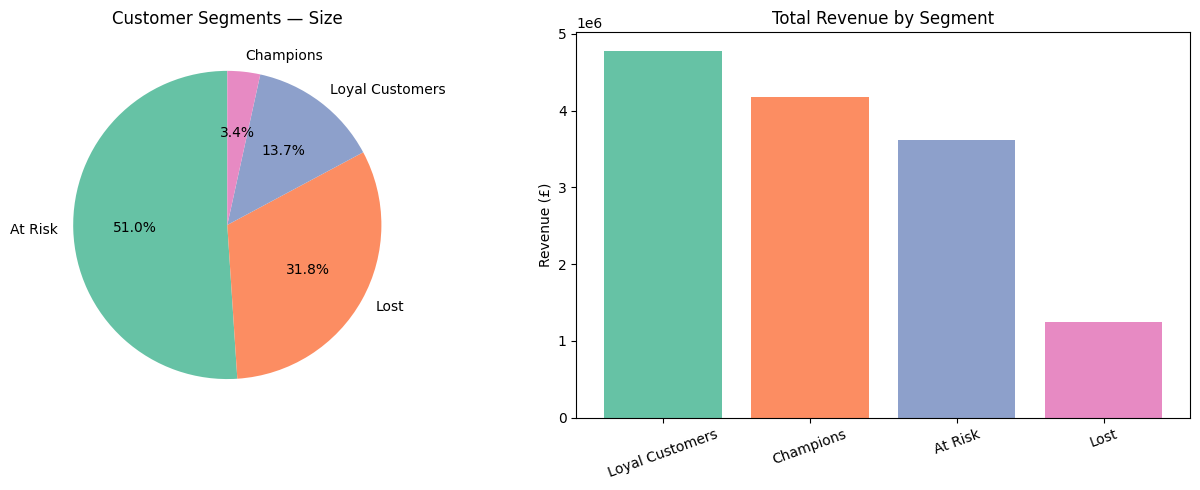

In [20]:
# Segment size pie chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

segment_counts = rfm_capped['Segment'].value_counts()
colors = sns.color_palette('Set2', len(segment_counts))
axes[0].pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Customer Segments — Size')

# Revenue contribution per segment
revenue_by_segment = rfm_capped.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
axes[1].bar(revenue_by_segment.index, revenue_by_segment.values, color=colors)
axes[1].set_title('Total Revenue by Segment')
axes[1].set_ylabel('Revenue (£)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('charts/05_segment_overview.png', dpi=150, bbox_inches='tight')
plt.show()

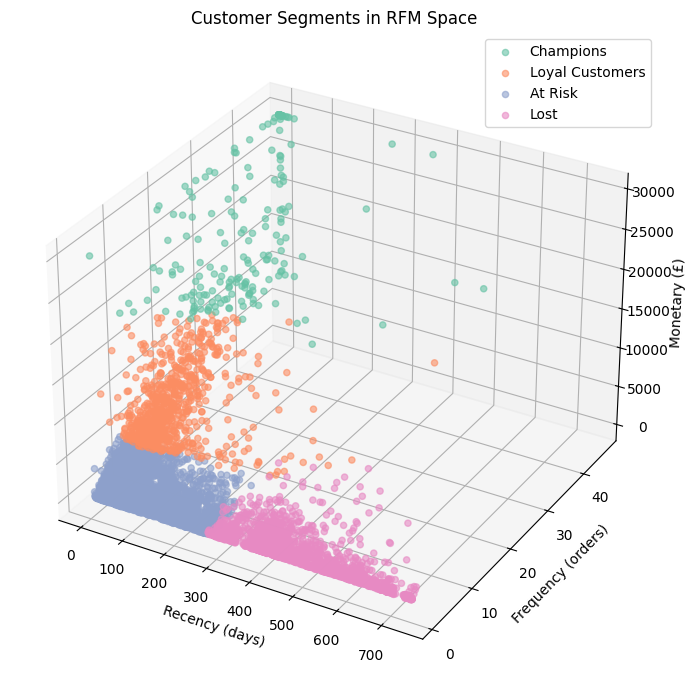

In [21]:
# 3D scatter of RFM colored by segment
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

for segment, color in zip(rfm_capped['Segment'].unique(), sns.color_palette('Set2', rfm_capped['Segment'].nunique())):
    subset = rfm_capped[rfm_capped['Segment'] == segment]
    ax.scatter(subset['Recency'], subset['Frequency'], subset['Monetary'],
               label=segment, alpha=0.6, color=color, s=20)

ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency (orders)')
ax.set_zlabel('Monetary (£)')
ax.set_title('Customer Segments in RFM Space')
ax.legend()
plt.tight_layout()
plt.savefig('charts/06_3d_segments.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Business recommendations per segment
This is the part that turns ML output into something a manager can act on.


In [22]:
recommendations = {
    'Champions': 'Reward with loyalty perks, early access to new products, and VIP treatment. Ask for reviews/referrals.',
    'Loyal Customers': 'Upsell and cross-sell. Encourage higher spend with bundle offers and personalized recommendations.',
    'At Risk': 'Send re-engagement campaigns with limited-time discounts before they churn completely.',
    'Lost': 'Low-cost win-back campaign (e.g. "We miss you" email). If no response, deprioritize marketing spend on this group.'
}


In [23]:
summary = cluster_profile.copy()
summary.index = summary.index.map(segment_names)
summary['Recommendation'] = summary.index.map(recommendations)
summary

,Recency,Frequency,Monetary,CustomerCount,Pct_of_Customers,Recommendation
Cluster,,,,,,
Lost,474.9,2.0,668.3,1868,31.8,"Low-cost win-back campaign (e.g. ""We miss you""..."
At Risk,83.5,3.8,1207.3,3000,51.0,Send re-engagement campaigns with limited-time...
Champions,36.6,34.1,20695.4,202,3.4,"Reward with loyalty perks, early access to new..."
Loyal Customers,44.1,14.8,5915.7,808,13.7,Upsell and cross-sell. Encourage higher spend ...


In [24]:
rfm_capped.to_csv('customer_segments.csv', index=False)
summary.to_csv('segment_summary.csv')


In [25]:
print('Saved: customer_segments.csv  (per-customer segment labels)')
print('Saved: segment_summary.csv    (segment-level profile + recommendations)')
print()
print('Step 3 COMPLETE. Ready for Step 4 (Streamlit dashboard).')


Saved: customer_segments.csv  (per-customer segment labels)
Saved: segment_summary.csv    (segment-level profile + recommendations)

Step 3 COMPLETE. Ready for Step 4 (Streamlit dashboard).


In [26]:
from google.colab import files
files.download('customer_segments.csv')
files.download('segment_summary.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>